# Mapping Environmental Risk Factors
## Overview
This project utilizes Google Earth Engine, and Michigan Open GIS data to create a environmental risk assessment of Michigan. The factors include
- Air Quality (Concentration of NO2)
- Water Quality (Concentration of PFOAs)
- Hazardous Waste dump and storage sites
By mapping these enivronmental indicators along with the population density of michigan, an environmental risk assessment map can be made. This map will show which areas of michigan are the most affected by high amounts of NO2, PFOAs, and hazzardous waste dump sites. 

## Problem Assessment and Level of Effort (Loe) 
Due to michigan being a historic paper producer and the sheer amount of industry within detroit, Michigan has released a myriad of toxic pollutants into the air and water. By mapping the amounts of NO2 (a gas created by the burning of fossil fuels), PFOAs (A chemical created as a byproduct in the paper making process), and hazardous waste storage and dump sites. We can see which counties have the most polluted environment. Then, by using a population density map, we can see which urban areas are at the most risk of air, water, and hazardous waste pollution.



**LOE**
- Find and clean data.... 1 Hour
- Import Landscan and environmental indicator maps.... 2 hours
- Create a michigan polygon to clip the Landscan to and clip the Landscan.... 30 minutes
- Combine Maps and create a environmental risk map.... 1.5 hours
- Write analysis.... 45 minutes
- Create a Github Repository and add everything related to the project.... 1 hour

## Introduction

**Part 1: Urban Density Map**
In order to find the environmental risk factors for michigan, we must first find the population density of michigan. We begin by bringing in Landscan data from Google Earth Engine. The data will then be exported into a .geoTIFF raster layer, and clipped onto a county basemap from ESRI

In [136]:
import ee
import geemap
import os
import geopandas as gpd
import ee
ee.Authenticate()
ee.Initialize(project="ee-walravenian843")



In [171]:
url = "https://services3.arcgis.com/dxRQUfTDNtfqZ301/arcgis/rest/services/County/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
counties = gpd.read_file(url)

#convert the county shp to an EE feature layer
selection_layer = geemap.gdf_to_ee(counties)
selection_layer

In [ ]:
#initialize Google Earth Engine
ee.Initialize(project='ee-walravenian843')
Map = geemap.Map()
Map


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
#load the population density map
dataset = ee.ImageCollection('CIESIN/GPWv411/GPW_Population_Density').first();
raster = dataset.select('population_density');
raster_vis = {
  'max': 1000.0,
  'palette': [
    'ffffe7',
    'FFc869',
    'ffac1d',
    'e17735',
    'f2552c',
    '9f0c21'
  ],
  'min': 200.0
};
Map.setCenter(79.1, 19.81, 3);
Map.addLayer(raster, raster_vis, 'population_density');
Map

Map(center=[19.81, 79.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:
#create the raster
dataset = ee.ImageCollection('CIESIN/GPWv411/GPW_Population_Density').first()
raster = dataset.select('population_density')


In [ ]:
#export the raster
task = ee.batch.Export.image.toDrive(
    image=raster,
    description='pop_density_michigan',
    scale=1000,
    region=gdf_mi_counties_ee.to_crs(4326).unary_union.bounds,
    fileFormat='GeoTIFF'
)
task.start()


In [ ]:
#bring in the new population density raster
import rasterio
import rasterio.mask
import numpy as np

pop_raster = rasterio.open("pop_density_michigan.tif")


**Part 1.5: County basemap**

In [ ]:
#creating the county bounds
url = "https://services3.arcgis.com/dxRQUfTDNtfqZ301/arcgis/rest/services/County/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
gdf_mi_counties = gpd.read_file(url)
gdf_mi_counties.info()

In [ ]:
#check the data
gdf_mi_test = gpd.read_file(url)
gdf_mi_test.head()

,OBJECTID,FIPSCode,Name,FeatureID,MapLayout,FIPSNum,Label,Type,CntyCode,Peninsula,MGFVersion,Shape__Area,Shape__Length,GlobalID,geometry
0,342,001,Alcona,51931f35-ce9a-491b-b699-49036d732254,landscape,1,Alcona County,County,1,Lower,V26,1.798557e+09,172519.815622,324fedbc-244e-40ef-89e2-ca15d2fdf578,"POLYGON ((-83.31858 44.51165, -83.31859 44.511..."
1,343,003,Alger,8c7dd4c5-6ac6-4734-842a-9435187285a1,landscape,3,Alger County,County,3,Upper,V26,2.424879e+09,390876.655767,65f15d53-82e4-46d8-a8c0-5c5d27749c7e,"MULTIPOLYGON (((-86.71656 46.47932, -86.71653 ..."
2,344,005,Allegan,174ea398-4ee3-4ab0-ac6e-6e91d33a682b,landscape,5,Allegan County,County,5,Lower,V26,2.180969e+09,192581.537228,e7e824d2-8e9d-4a54-9ca5-b86a82a9f815,"POLYGON ((-85.5432 42.42144, -85.54645 42.4214..."
3,345,007,Alpena,ee696d1a-c271-4a50-90f1-96c683eebd97,landscape,7,Alpena County,County,7,Lower,V26,1.539373e+09,288786.046530,2f175508-f9f8-4c16-a608-9ec9c7117f17,"MULTIPOLYGON (((-83.36396 44.89366, -83.36421 ..."
4,346,009,Antrim,a349ee7e-448e-40bb-8bbb-cdf44a483d6e,landscape,9,Antrim County,County,9,Lower,V26,1.358721e+09,180700.647106,feaa7f06-1876-4d7e-97ff-faa297bab6d5,"MULTIPOLYGON (((-85.41791 44.90024, -85.41799 ..."


Here we can see all the Counties of michigan and all their attributes

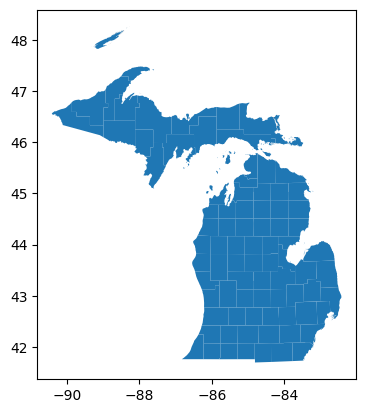

In [ ]:
#change the CRS of the GDf to 4326
gdf_mi_counties_ee = gdf_mi_counties[["county_id", "geometry"]].to_crs(5070).copy()
gdf_mi_counties_ee["geometry"] = gdf_mi_counties_ee.geometry.simplify(250, preserve_topology=True)
gdf_mi_counties_ee = gdf_mi_counties_ee.to_crs(4326)

gdf_mi_counties_ee.plot();

In [ ]:
gdf_mi_counties_ee.columns



Index(['county_id', 'geometry'], dtype='object')

**Part 1.75: population density of Michigan**

In [ ]:
#use rasterio to extract mean population density from the raster
gdf_mi_counties_4326 = gdf_mi_counties_ee.to_crs(4326)


pop_density = []

for idx, row in gdf_mi_counties_4326.iterrows():
    geom = [row["geometry"]]

    try:
        out_image, _ = rasterio.mask.mask(pop_raster, geom, crop=True)
        data = out_image[0]

        # Remove nodata and zeros
        data = data[data > 0]

        if len(data) == 0:
            pop_density.append(0)
        else:
            pop_density.append(float(np.mean(data)))

    except Exception as e:
        pop_density.append(0)


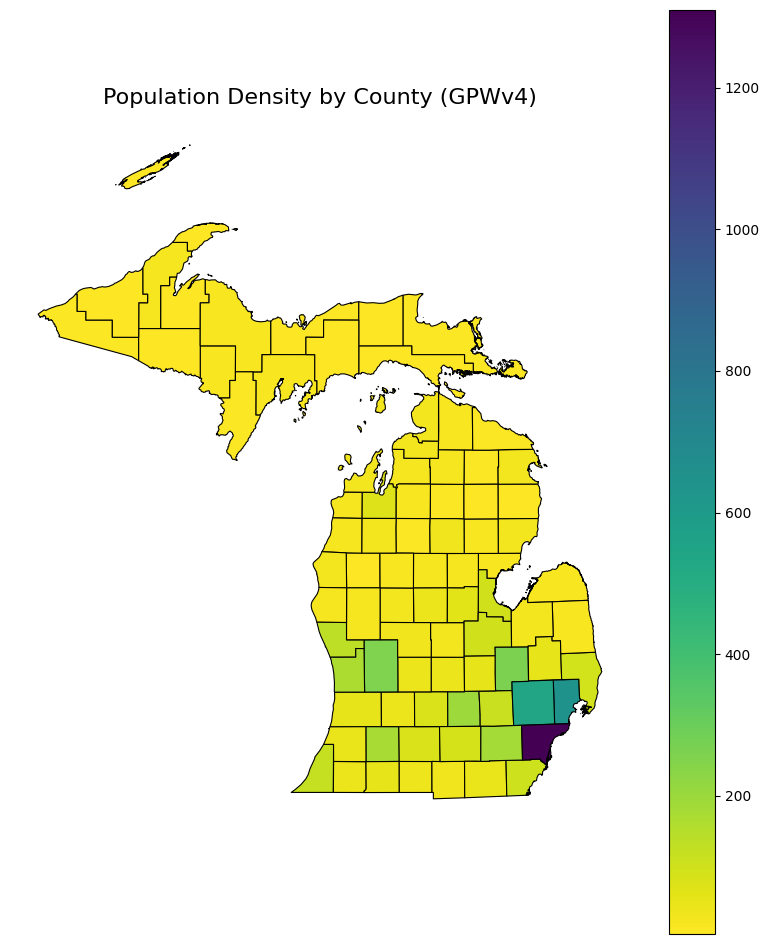

In [ ]:
#plot the map
gdf_mi_counties_4326["pop_density"] = pop_density

fig, ax = plt.subplots(figsize=(10, 12))

gdf_mi_counties_4326.plot(
    ax=ax,
    column="pop_density",
    cmap="viridis_r",   # darker = more dense
    linewidth=0.8,
    edgecolor="black",
    legend=True
)

ax.set_title("Population Density by County", fontsize=16)
ax.set_axis_off()
plt.show()


From the population dnesity graph, we can see that the county with the highest population density is Wayne county

**Part 2: Air Quality Map**

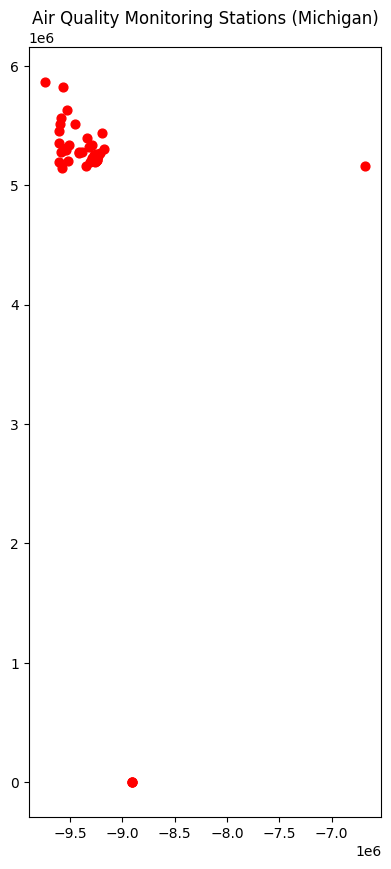

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("Air Quality.csv")

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["X"], df["Y"]),
    crs="EPSG:4326"   # your coordinates are already Web Mercator
)

# Plot
fig, ax = plt.subplots(figsize=(8, 10))
gdf.plot(ax=ax, color="red", markersize=40)

ax.set_title("Air Quality Monitoring Stations (Michigan)")
plt.show()



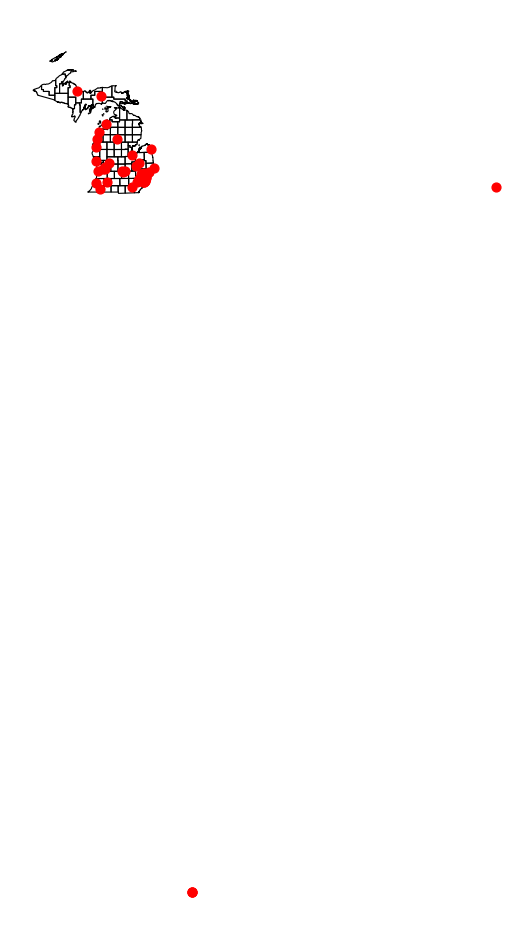

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

#loading CSV again just in case
df = pd.read_csv("Air Quality.csv")

#making a GeoDataFrame for points
gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["X"], df["Y"]),
    crs="EPSG:3857"   # your CSV uses Web Mercator
)

#matching CRS 
gdf_mi_counties_ee = gdf_mi_counties_ee.to_crs(3857)
gdf_points = gdf_points.to_crs(3857)

#Plot the map
fig, ax = plt.subplots(figsize=(10, 12))

# Counties (basemap)
gdf_mi_counties_ee.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.8,
    zorder=1
)

# air quality points
gdf_points.plot(
    ax=ax,
    color="red",
    markersize=40,
    zorder=3
)

ax.set_axis_off()
plt.show()

This is all of the points where air quality is being sampled across Michigan. Now we need to filter for the amount of NO2. From the cell below, we can see the structure of the data. we know that the exact variable name we are filtering for is NO2_PPB

In [ ]:
df.head()


,X,Y,OBJECTID,StationId,StationName,StationType,StationStatus,LastObservation,WD_DEGREES,WS_MS,...,OZONE_PPB,NO2_PPB,SO2_PPB,CO_PPM,NO_PPB,PM10_UGM3,NOX_PPB,RWD_DEGREES,NOY_PPB,RWS_KNOTS
0,-9.590068e+06,5.276709e+06,1,260050003,Holland,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,NaN,3.1,NaN,NaN,NaN,NaN,NaN,164.0,NaN,5.2
1,-9.338693e+06,5.399398e+06,2,260170014,Bay City,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.0,NaN,4.3
2,-9.607927e+06,5.190704e+06,3,260210014,Coloma,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,175.0,NaN,2.6
3,-9.573646e+06,5.145398e+06,4,260270003,Cassopolis,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172.0,NaN,7.0
4,-9.314139e+06,5.319178e+06,5,260490021,Flint,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_no2 = df[df["NO2_PPB"] > 1]
df_no2.head()


,X,Y,OBJECTID,StationId,StationName,StationType,StationStatus,LastObservation,WD_DEGREES,WS_MS,...,OZONE_PPB,NO2_PPB,SO2_PPB,CO_PPM,NO_PPB,PM10_UGM3,NOX_PPB,RWD_DEGREES,NOY_PPB,RWS_KNOTS
0,-9.590068e+06,5.276709e+06,1,260050003,Holland,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,NaN,3.1,NaN,NaN,NaN,NaN,NaN,164.0,NaN,5.2
8,-9.413500e+06,5.275763e+06,9,260650018,Lansing,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,27.0,7.4,1.4,NaN,3.1,7.0,10.5,181.0,NaN,5.2
10,-9.536885e+06,5.309554e+06,11,260810020,Grand Rapids - Monroe St.,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,NaN,11.0,0.1,NaN,2.8,12.0,NaN,165.0,14.2,5.2
12,-9.537815e+06,5.294585e+06,13,840260810023,Grand Rapids Near Road,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,NaN,16.9,NaN,0.0,5.5,NaN,22.4,156.0,NaN,6.1
34,-9.251395e+06,5.206414e+06,35,261630015,Detroit - SW,Permanent,Active,2026/02/24 13:00:00+00,NaN,NaN,...,NaN,17.8,0.4,NaN,3.1,22.0,21.0,235.8,NaN,1.9


This creates a new database with all the instances of a NO2 concentration over 1 PPB. From here, we can put it back into our counties basemap, reduce it and find the counties with high amounts (>1PPB) of NO2

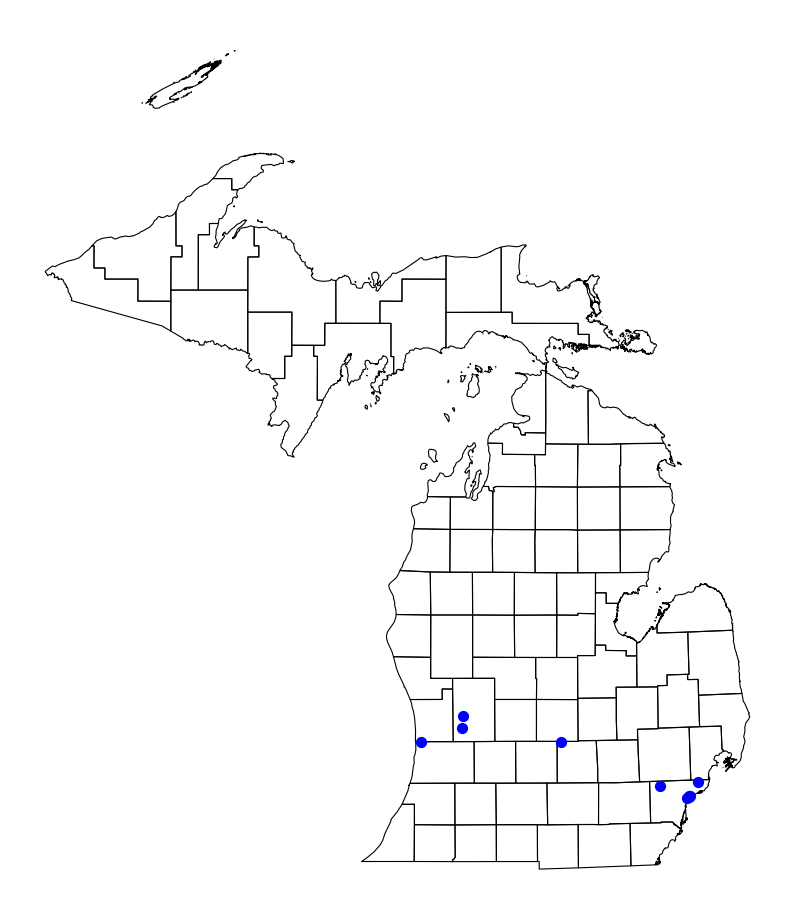

In [ ]:
# Convert filtered rows into a GeoDataFrame
gdf_no2 = gpd.GeoDataFrame(
    df_no2,
    geometry=gpd.points_from_xy(df_no2["X"], df_no2["Y"]),
    crs="EPSG:3857")

# Match CRS with counties
gdf_no2 = gdf_no2.to_crs(3857)
gdf_mi_counties_ee = gdf_mi_counties_ee.to_crs(3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))

# Counties (basemap)
gdf_mi_counties_ee.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.8,
    zorder=1
)

# Filtered NO2 points
gdf_no2.plot(
    ax=ax,
    color="blue",
    markersize=50,
    zorder=3
)

ax.set_axis_off()
plt.show()

Great, now to obtain the count of points per county. this will allow us to map the counties with high concentrations of NO2

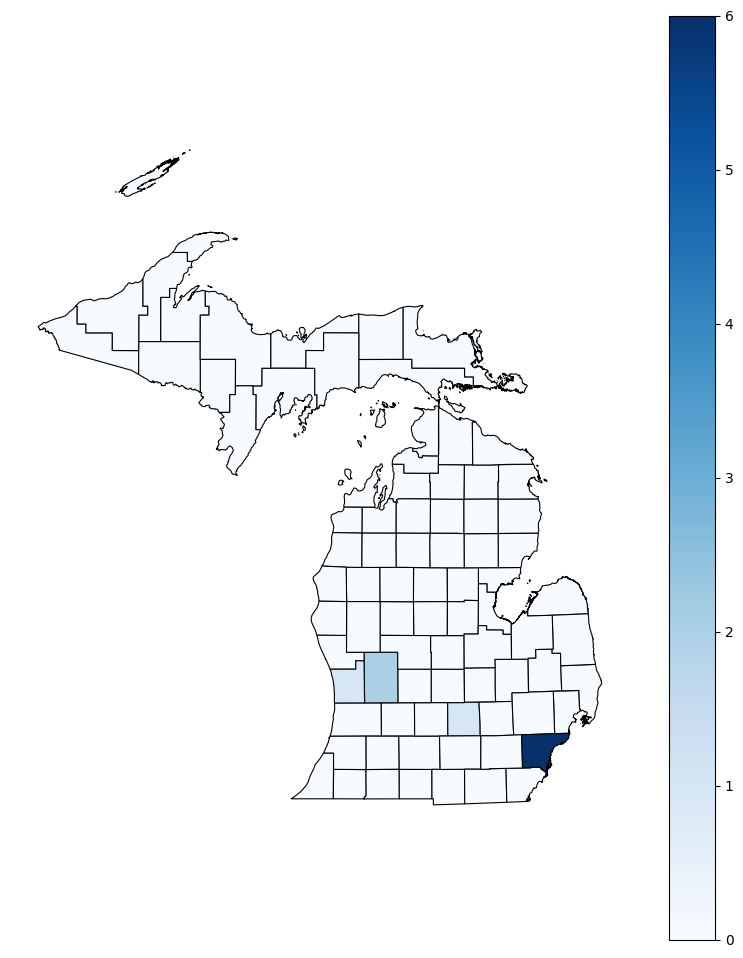

In [ ]:
#join the data
joined = gpd.sjoin(gdf_no2, gdf_mi_counties_ee, how="inner", predicate="within")

#create a count of points per county
counts = joined.groupby("county_id").size().reset_index(name="point_count")

#merge it all back together
gdf_counties = gdf_mi_counties_ee.merge(counts, on="county_id", how="left")

#replace the NaN with 0 so we can see all the counties
gdf_counties["point_count"] = gdf_counties["point_count"].fillna(0)

#Plot
fig, ax = plt.subplots(figsize=(10, 12))

gdf_counties.plot(
    ax=ax,
    column="point_count",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="black",
    legend=True
)

ax.set_axis_off()
plt.show()

We can see that wayne county has a relativly high concentration of NO2 (~6 PPB). In addition to this, Ingham, Ottawa, and Kent counties have measures of NO2 that are considered unsafe by the EPA (>1 PPB). 

**Part 3: PFOAs Map**

First I want to call the head of the PFOAs csv to see which attribute we will be working with 

In [ ]:

#loading PFOA dataset
df_pfoa = pd.read_csv("PFOAs Amounts.csv")

# Show the first few rows
df_pfoa.head()


,X,Y,LabSampleId,SiteCode,CocSampleId,SampleType,LabName,LabJobName,Matrix,CollectionDate,...,CAS919005144_ADONA,CAS919005144_ADONAFlag,CAS919005144_ADONAMdl,CAS919005144_ADONARl,CreatedUser,CreatedDate,LastEditedUser,LastEditedDate,GlobalID,OBJECTID
0,707481.861085,435146.117956,320-58401-1,02-CM-0060,CLARKS MARSH SOUTH,Depth Integrated,TestAmerica Sacramento,320-58401-1,Water,2020/02/03 00:00:00+00,...,0.16,K,0.16,1.80,NaN,NaN,NaN,NaN,{F11B6A1C-F05D-4A3C-9E8A-933BF3335EA0},1
1,708583.275773,442891.475456,SL-0100,02-SL-0010,SL-0100,NaN,Vista Analytical,2109148,H20,2021/09/01 00:00:00+00,...,1.00,K,1.00,4.01,NaN,NaN,NaN,NaN,{F4C7FCC1-4D8F-4202-994E-44B9FB252313},2
2,704007.196274,434875.592448,2209070-16,02-AS-0150,AS-0150,NaN,EGLE,2209070,H2O,2022/09/08 00:00:00+00,...,2.00,K,0.40,2.00,NaN,NaN,NaN,NaN,{6A7938C1-3269-4F59-8E11-59E9B55472B2},3
3,705052.203565,443247.372675,2209070-18,02-HC-0030,HC-0030,NaN,EGLE,2209070,H2O,2022/09/08 00:00:00+00,...,2.00,K,0.40,2.00,NaN,NaN,NaN,NaN,{659047AC-71B4-43D7-81BE-1D5A083535DF},4
4,602504.876876,457789.183104,2209069-09,02-AS-0800,AS-0800,NaN,EGLE,2209069,H2O,2022/09/07 00:00:00+00,...,2.00,K,0.40,2.00,NaN,NaN,NaN,NaN,{49D0F71C-832D-47C4-9FE6-AEFD3F303330},5


Unfortunatly, there are too many collumns to see them all from a simple .head command. To see all the variables within the csv a .columns command must be ran

In [ ]:
for col in df_pfoa.columns:
    print(col)


X
Y
LabSampleId
SiteCode
CocSampleId
SampleType
LabName
LabJobName
Matrix
CollectionDate
AnalysisMethod
DilutionFactor
AnalysisDate
Duplicate
Unit
Watershed
Waterbody
LocationCode
HUC10
HUC8
Project
Description
AdditionalDescription
VisitID
SampleDepth
Longitude
Latitude
CAS307244_PFHxA
CAS307244_PFHxAFlag
CAS307244_PFHxAMdl
CAS307244_PFHxARl
CAS307551_PFDoA
CAS307551_PFDoAFlag
CAS307551_PFDoAMdl
CAS307551_PFDoARl
CAS335671_PFOA
CAS335671_PFOAFlag
CAS335671_PFOAMdl
CAS335671_PFOARl
CAS335762_PFDA
CAS335762_PFDAFlag
CAS335762_PFDAMdl
CAS335762_PFDARl
CAS335773_PFDS
CAS335773_PFDSFlag
CAS335773_PFDSMdl
CAS335773_PFDSRl
CAS355464_PFHxS
CAS355464_PFHxSFlag
CAS355464_PFHxSMdl
CAS355464_PFHxSRl
CAS356025_33FTCA
CAS356025_33FTCAFlag
CAS356025_33FTCAMdl
CAS356025_33FTCARl
CAS375224_PFBA
CAS375224_PFBAFlag
CAS375224_PFBAMdl
CAS375224_PFBARl
CAS375735_PFBS
CAS375735_PFBSFlag
CAS375735_PFBSMdl
CAS375735_PFBSRl
CAS375859_PFHpA
CAS375859_PFHpAFlag
CAS375859_PFHpAMdl
CAS375859_PFHpARl
CAS375928_PFHp

The variable that pertains to PFOAs concentrations is CAS335671_PFOA. 
A concentration of PFOAs greater than 8 PPM is considered to be toxic by EGLE. However any amount of PFOAs in a water body over 0.8 PPM is considered to be hazardous to humans. For the environmental risk analysis, any concentrationof PFOAs greater than 0.8 PPM will be analyzed. 


Much like the previous data, this data will be filtered for any point that has a concentrtion over 0.8 PPM. The data will then be joined, and later merged by county and mapped to show counties that contain high levels of PFOAs.

In [ ]:
#filter PFOA data for CAS335671_PFOA > 0.8
df_pfoa_filtered = df_pfoa[df_pfoa["CAS335671_PFOA"] > 0.8]

#checking the PFOAs collumn
df_pfoa_filtered["CAS335671_PFOA"]


0       120.0
1         1.0
2         2.0
3         0.9
4         2.0
        ...  
3714      5.3
3715      8.8
3716      2.8
3717      0.9
3718      1.6
Name: CAS335671_PFOA, Length: 3065, dtype: float64

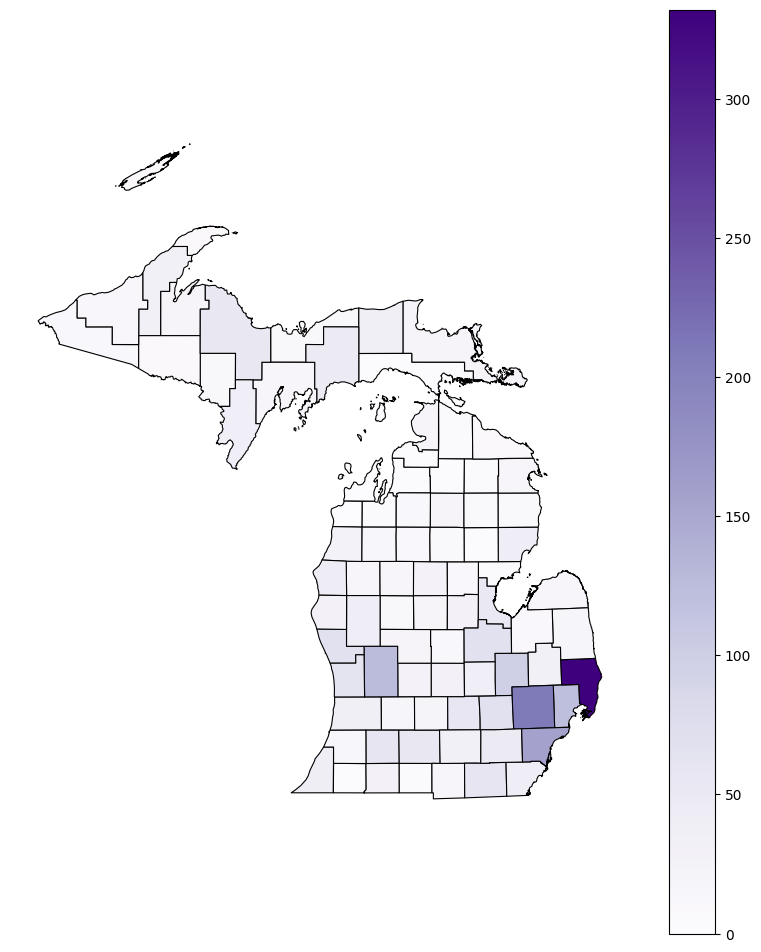

In [ ]:
#create a dataframe for filtered data
gdf_pfoa = gpd.GeoDataFrame(
    df_pfoa_filtered,
    geometry=gpd.points_from_xy(
        df_pfoa_filtered["Longitude"],
        df_pfoa_filtered["Latitude"]
    ),
    crs="EPSG:4326"   # lat/lon
).to_crs(3857)


#match CRS
gdf_pfoa = gdf_pfoa.to_crs(3857)
gdf_mi_counties_ee = gdf_mi_counties_ee.to_crs(3857)

#join the data
joined_pfoa = gpd.sjoin(gdf_pfoa,gdf_mi_counties_ee,how="inner",predicate="intersects")


#create counts for PFOAs per county
pfoa_counts = joined_pfoa.groupby("county_id").size().reset_index(name="pfoa_count")

#merge the data
gdf_pfoa_counties = gdf_mi_counties_ee.merge(pfoa_counts, on="county_id", how="left")

#replace NaN with 0 so we can see the counties
gdf_pfoa_counties["pfoa_count"] = gdf_pfoa_counties["pfoa_count"].fillna(0)

#plot it
fig, ax = plt.subplots(figsize=(10, 12))

gdf_pfoa_counties.plot(
    ax=ax,
    column="pfoa_count",
    cmap="Purples",
    linewidth=0.8,
    edgecolor="black",
    legend=True
)

ax.set_axis_off()
plt.show()

**Part 4: Hazardous Waste Map**

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

#Load the CSV
df_haz = pd.read_csv("Hazardous Waste Sites.csv")

#check the data columns and look for a testable variable
for i, c in enumerate(df_haz.columns):
    print(i, c)



0 X
1 Y
2 WDSId
3 SiteId
4 SiteSpecificName
5 LegalName
6 Address
7 City
8 County
9 Latitude
10 Longitude
11 CoordinateSystem
12 HorizontalCollectionMethod
13 FacilityType
14 Commercial
15 CommercialFacility
16 PermitWorkLoad
17 CorrectiveActionWorkLoad
18 FederallyRegulatedTSD
19 Permitted
20 CorrectiveActionAndPermit
21 Hyperlink
22 Echo
23 Updated


The variable we will be using for this analysis will be FacilityType. This variable does not contain any numbers, but is instead coded with single letter facility codes. The facility codes we will use for this analysis will be S (hazardous waste storage areas) and D (hazardous waste disposal sites). 

In [ ]:
#filtering for S and D facilities
df_haz_filtered = df_haz[df_haz["FacilityType"].isin(["S", "D"])]

df_haz_filtered[["FacilityType"]].head(20)


,FacilityType
1,S
6,S
9,S
11,S
12,D
13,S
14,S
15,S
18,S
20,S


We have successfully filtered the data, now to map the amount of sites per county

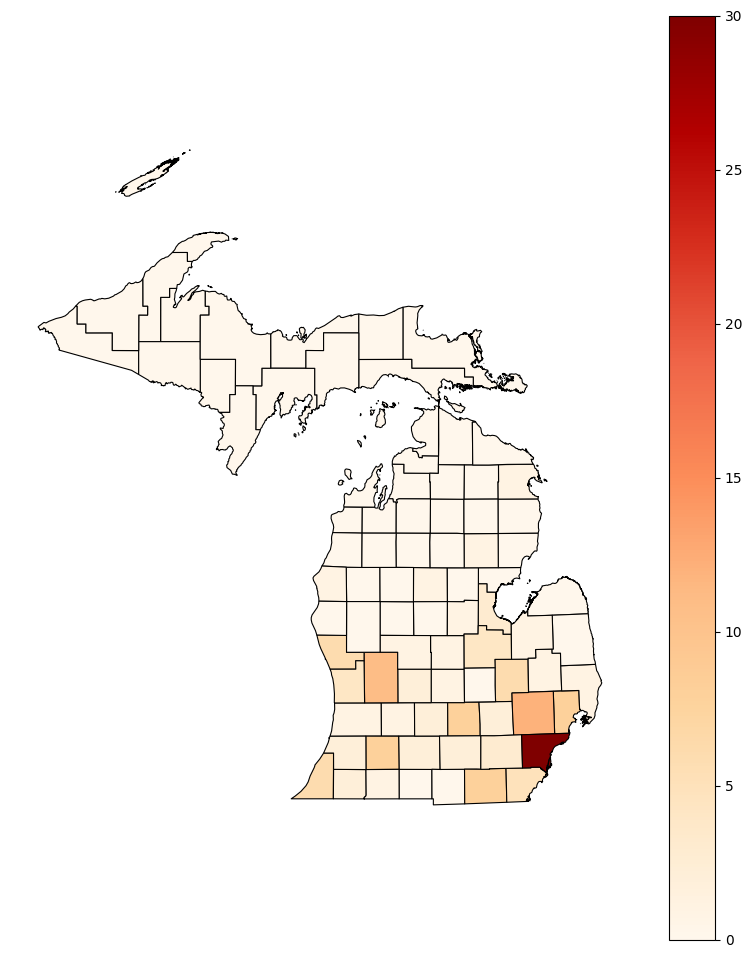

In [ ]:
#create a geodataframe
gdf_haz = gpd.GeoDataFrame(
    df_haz_filtered,
    geometry=gpd.points_from_xy(
        df_haz_filtered["Longitude"],
        df_haz_filtered["Latitude"]
    ),
    crs="EPSG:4326"   # WGS-84
).to_crs(3857)        # match counties

#join the data
joined_haz = gpd.sjoin(
    gdf_haz,
    gdf_mi_counties_ee,
    how="inner",
    predicate="intersects"
)

#create a count per county
haz_counts = joined_haz.groupby("county_id").size().reset_index(name="haz_count")

#merge the data
gdf_haz_counties = gdf_mi_counties_ee.merge(haz_counts, on="county_id", how="left")
gdf_haz_counties["haz_count"] = gdf_haz_counties["haz_count"].fillna(0)

#plot the map
fig, ax = plt.subplots(figsize=(10, 12))

gdf_haz_counties.plot(
    ax=ax,
    column="haz_count",
    cmap="OrRd",
    linewidth=0.8,
    edgecolor="black",
    legend=True
)

ax.set_axis_off()
plt.show()


## Results

For the analysis, the three environmental factor maps will be merged together to create an environmental risk map. This map will then be weighted by populationn density. the map will then be analyzed to see which counties of michigan expose the most individuals to the most amount of pollution. 

In [ ]:
#rename column names for NO2 data so maps can be merged
gdf_no2_counties = gdf_counties.rename(columns={"point_count": "no2_count"})


In [ ]:
#combine the GDFs
gdf_combined = gdf_mi_counties_ee.copy()

gdf_combined = gdf_combined.merge(
    gdf_no2_counties[["county_id", "no2_count"]],
    on="county_id",
    how="left"
)

gdf_combined = gdf_combined.merge(
    gdf_pfoa_counties[["county_id", "pfoa_count"]],
    on="county_id",
    how="left"
)

gdf_combined = gdf_combined.merge(
    gdf_haz_counties[["county_id", "haz_count"]],
    on="county_id",
    how="left"
)


After merging the data, it must be normalized. Each attribute that was analyzed has a different scale. in order to directly compare concentrations of PFOAs, NO2, and hazardous waste sites. 

In [ ]:
#normalizing the data
for col in ["no2_count", "pfoa_count", "haz_count"]:
    gdf_combined[col + "_norm"] = (
        gdf_combined[col] - gdf_combined[col].min()
    ) / (gdf_combined[col].max() - gdf_combined[col].min())


In [ ]:
#combine the maps
gdf_combined["risk_index"] = (gdf_combined["no2_count_norm"] +gdf_combined["pfoa_count_norm"] +gdf_combined["haz_count_norm"])


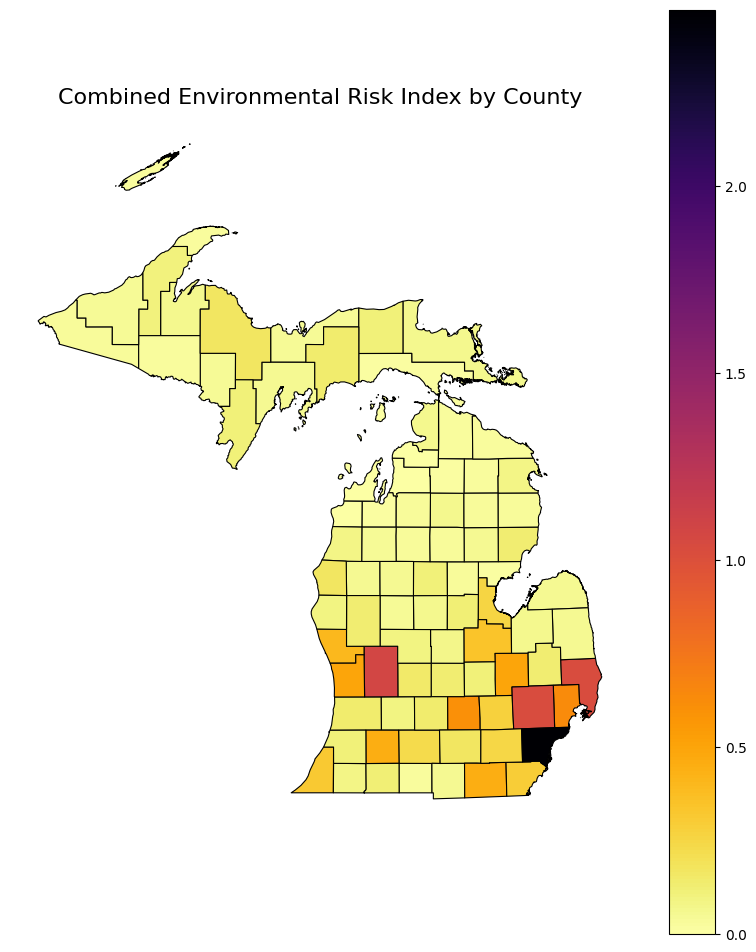

In [ ]:
#plot the map
fig, ax = plt.subplots(figsize=(10, 12))

gdf_combined.plot(
    ax=ax,
    column="risk_index",
    cmap="inferno_r",
    linewidth=0.8,
    edgecolor="black",
    legend=True)

ax.set_title("Combined Environmental Risk Index by County", fontsize=16)
ax.set_axis_off()
plt.show()


From the unweighted risk assessment map, we can see that Wayne and surrounding counties has an extremely high amount of environmental risk factors. Kent county is an outlier. while the counties neighboring Kent county have somewhat high amounts of environmental risk, kent has almost double the amount of risk factors

The next step is to weigh the counties by population density to creat a calculated environmental risk score

In [150]:
#change the name of the pop density for easier coding
gdf_pop_counties = gdf_mi_counties_4326.copy()

#reset the global database
gdf_combined = gdf_mi_counties_4326[["county_id", "geometry"]].copy()


It is imperative to reset the databse here. If the database is not reset, then there will be duplicate columns and errors will occur later on in the notebook.

In [143]:
#add population density
gdf_pop_counties["pop_density"] = pop_density

#check the data
gdf_pop_counties.columns


Index(['county_id', 'geometry', 'pop_density'], dtype='object')

In [151]:
#adding the environmental risk factors
# NO2
gdf_combined = gdf_combined.merge(
    gdf_no2_counties[["county_id", "no2_count"]],
    on="county_id",
    how="left"
)

# PFOA
gdf_combined = gdf_combined.merge(
    gdf_pfoa_counties[["county_id", "pfoa_count"]],
    on="county_id",
    how="left"
)

# Hazardous Waste
gdf_combined = gdf_combined.merge(
    gdf_haz_counties[["county_id", "haz_count"]],
    on="county_id",
    how="left"
)


In [152]:
#add in the population density
gdf_combined = gdf_combined.merge(
    gdf_pop_counties[["county_id", "pop_density"]],
    on="county_id",
    how="left"
)

#check the data
gdf_combined.columns


Index(['county_id', 'geometry', 'no2_count', 'pfoa_count', 'haz_count',
       'pop_density'],
      dtype='object')

Now we clearly have NO2, PFOAs, Hazardous Waste Sites, County Id, and Population Density in one clean geodatabase. Now we can weigh the factors by the population density to create the final map

In [160]:
#amplify the amount of risk by population density 
gdf_combined["no2_weighted"] = gdf_combined["no2_count"] * gdf_combined["pop_density"]
gdf_combined["pfoa_weighted"] = gdf_combined["pfoa_count"] * gdf_combined["pop_density"]
gdf_combined["haz_weighted"] = gdf_combined["haz_count"] * gdf_combined["pop_density"]

#create the enviromental exposure index
gdf_combined["env_exposure_index"] = (
    gdf_combined["no2_weighted"]
    + gdf_combined["pfoa_weighted"]
    + gdf_combined["haz_weighted"]
)


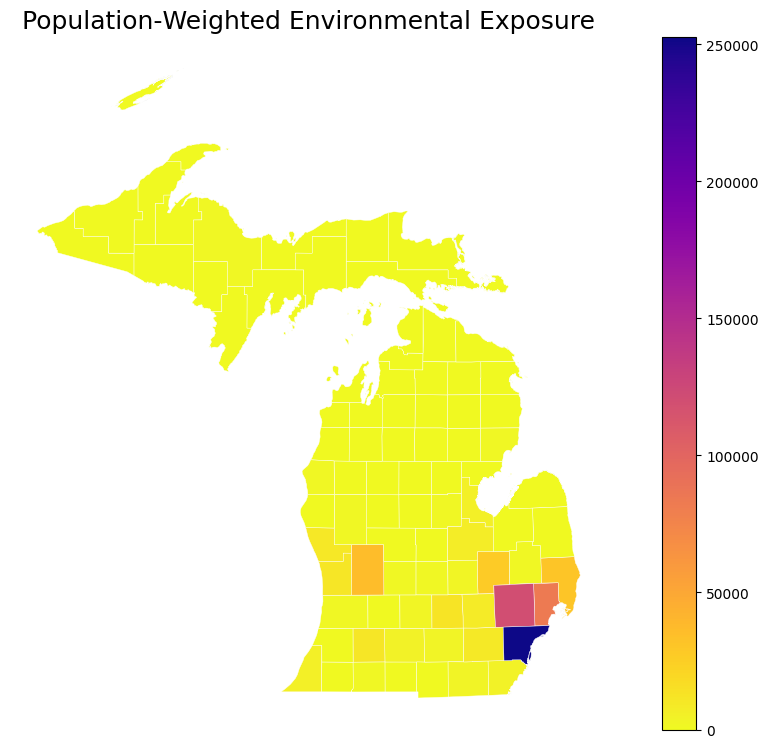

In [163]:
#potting the map
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(14, 9))

gdf_combined.plot(
    column="env_exposure_index",
    cmap="plasma_r",
    k=5,
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.3
)

ax.set_title("Population‑Weighted Environmental Exposure", fontsize=18)
ax.axis("off")
plt.show()


Great now we finally have the calculated Environmental rsik score weighed by population density.

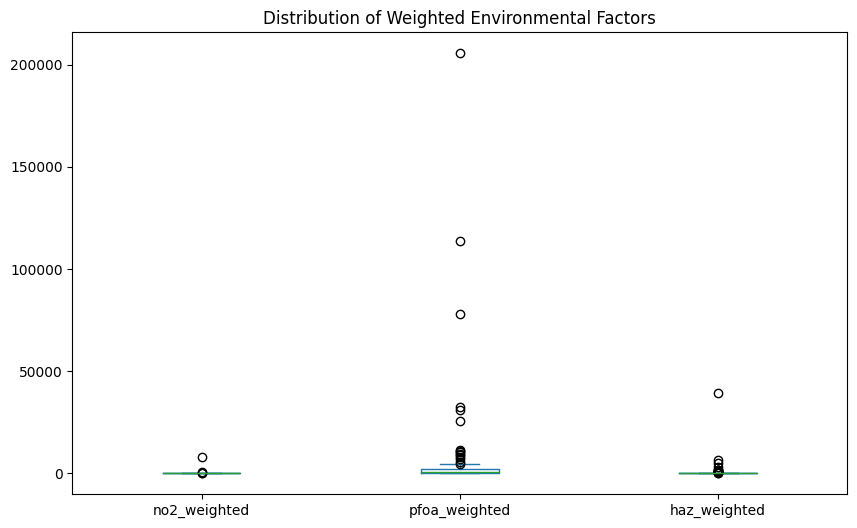

In [ ]:
import matplotlib.pyplot as plt

gdf_combined[["no2_weighted", "pfoa_weighted", "haz_weighted"]].plot(
    kind="box",
    figsize=(10,6),
    title="Distribution of Weighted Risk Factors"
)
plt.show()



This chart shows the distribution of the weighted environmental risk factors. We can see that the amount of PFOAs has a lot of significantly higher outlier than the other risk fators. This could skew our data as the highest outlier for FPOAs is located within Wayne county, the county with the highest amount of environmental risk. 

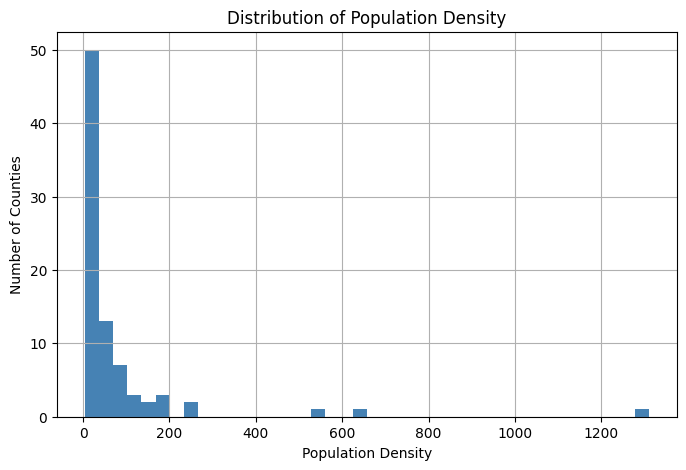

In [169]:
import matplotlib.pyplot as plt

gdf_combined["pop_density"].hist(bins=40, figsize=(8,5), color="steelblue")
plt.title("Distribution of Population Density")
plt.xlabel("Population Density")
plt.ylabel("Number of Counties")
plt.show()


Here we can see the amount of counties grahped into a histogram based upon their population density. Once again there is a small amount of outliers with more than double the population density of the majority of the counties. These outlier can skew our data. I believe that the county that is located on the far right of the map is Wayne county.

## Conclusion

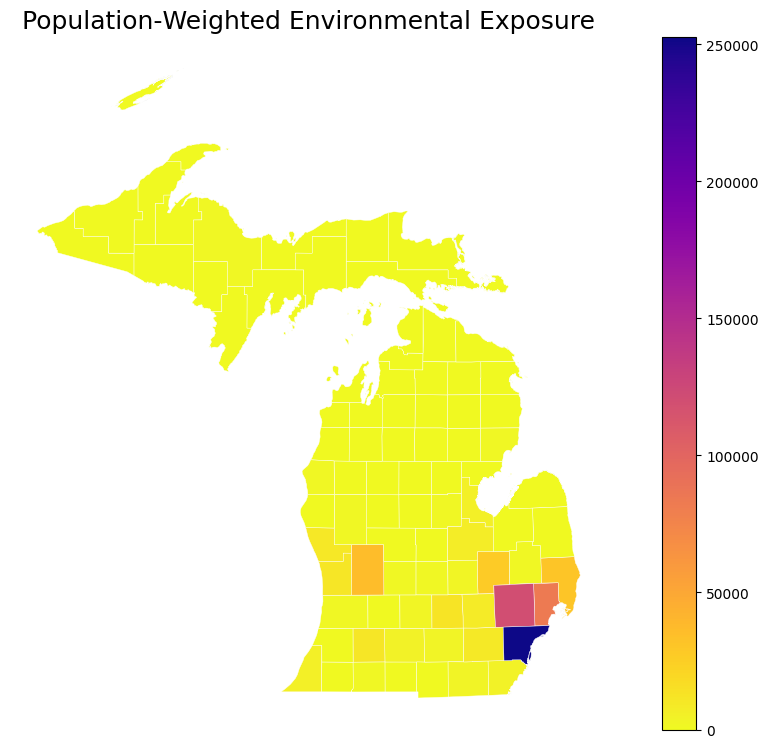

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(14, 9))

gdf_combined.plot(
    column="env_exposure_index",
    cmap="plasma_r",
    k=5,
    legend=True,
    ax=ax,
    edgecolor="white",
    linewidth=0.3
)

ax.set_title("Population‑Weighted Risk Exposure", fontsize=18)
ax.axis("off")
plt.show()


**Part 1: What the data shows**

From our weighted environmental risk map, we can see that Wayne, Kent, Oakland, Malcomb, and St. Claire conties are at a high risk of coming into contact with high amounts of NO2, PFOAs, and hazardous waste sites. The county with the highest risk factor is Wayne county. However, this could be due to the skewing of the PFOAs data as shown in the previous data distribution box graph. Wayne county had a single PFAs surface sampling point. This point found a concentration of PFOAs over 200,000, which is extremely toxic.

The data was also amplified by population density so that counties with higher population densities were weighed more heavily than counties without a high population density. As the distribution of population density shows, one single county one has a population density of ~1300. This is almost double the population density of the second highest county. Unsurprisingly, the county with the highest population density is Wayne county. while the data may be skewed due to the wayne these attributes, it goes to show how big the risk factor for the county is. With waterbodies testing high for PFOAs and a high population density, the amount of individuals who could be exposed to PFOAs from fishing, swiming, or boating is scarily high. 

**Part 2: Limitations**

This project was wrought with errors and workarounds for those errors. One of the biggest problems that I faced was merging the Google Earth Engine data with the county basemap. My original plan was to clip the GEE layer to the county basemap, but it would never work. In GEE, there is a bite limit to what can be extracted. The sheer amount of population density points would always reach the bite limit and for a while I thought nothuing could be done. To remedy this, i exported the data directly from GEE and turned it into a raster. From there I downloaded Rasterio, a python library used for editing and analyzing raster layers. From there, I clipped the population density to the basemap. 

Another problem I was faced with was time. In my original LOE, I assumed this project would take 7-8 hours to create. However, this was not the case. I have worked a total of 17 hours on this project and have no more time to tweak my charts and maps. I never assumed that time would be a limit of this project, but after working on it for almos a complete day I realized that to create an actual professional project like this, I needed to give myself more time to make sure each cell works fine on its own. As it stands now, the code cells can only be ran in a direct linear order. I change variables values a lot which can sometimes make running previous code cells return an error. If i had more time, I would try to make it so that each cell can be ran by itself to eliminate that problem.

**Part 3: Going Forward**

Going forward, I would like to normalize the environmental risk factors to minimize the skewedness from the extremely high outliers. from the box plots we can see that each risk factor has high outliers. This high outlier is also seen in the population density by county histogram. Going foreward I would like to use a logarithmic function to normalize the data so that all the counties can be compared. As it is now, my Weighted Environmental Risk map is being skewed by wayne county and most of the other counties show only low risk compared to wayne county. While this does show the counties with the highest risk, all the other counties fall by the wayside. if future research is done with this data, the data should be transformed to show a normalized bell curve. 

In addition to normalizing the data, future researchers should also obtain NO2 data from other sources as well. While the source that I used yielded a decent map, there were no NO2 sampling points in the Upper Peninsula. Possibly by using a different data source than the Mmichigan Open GIS database they could find NO2 sampling points across the enitre state. While the other risk factors had low values within the upper peninsula, the lack of NO2 data in that area makes me less happy about my maps because I could be missing vital data. 